In [111]:
import numpy as np
import matplotlib.pyplot as plt
from gillespie import random_sample

In [112]:
def get_xhigh(k1, k2):
    disc = k1**2 - 4 * k2
    return (k1 + np.sqrt(disc)) / (2 * k2)

def get_xcrit(k1, k2):
    disc = k1**2 - 4 * k2
    return (k1 - np.sqrt(disc)) / (2 * k2)

In [113]:
X, W = 0, 1

def build_reaction(system_size, k1, k2):

    k1_propensity = 2.0 * k1 / system_size
    k2_propensity = 6.0 * k2 / system_size**2

    reactions = [
        ((X, X),       (X, X, X), k1_propensity),
        ((X, X, X),    (X, X),    k2_propensity),
        ((X,),         (W,),      1), 
    ]

    return reactions

In [114]:
def get_trajectory(system_size, initial_concentration, duration, k1, k2):
    reaction = build_reaction(system_size, k1, k2)
    scaled_concentration = int(round(initial_concentration * system_size))
    init_state = [scaled_concentration, 0]
    times = np.array([0.0, duration])
    return random_sample(reaction, init_state, times)

In [115]:
def get_final_result(system_size, concentration, duration, k1, k2):

    reaction = build_reaction(system_size, k1, k2)
    initial_x = int(round(concentration * system_size))
    init_state = [initial_x, 0]

    times = np.array([0.0, duration])
    traj = random_sample(reaction, init_state, times)

    final = traj[-1, X]
    return final / system_size

In [116]:
def get_dilution_rate(k1, k2, x_high, total_runs, duration, concentration, system_size):

    rate = 0

    for _ in range(total_runs):
        final = get_final_result(system_size, concentration, duration, k1, k2)
        if final < x_high / 2:
            rate += 1

    return rate

In [117]:
def get_amplification_rate(k1, k2, x_high, total_runs, duration, concentration, system_size):
    
    rate = 0

    for _ in range(total_runs):
        final = get_final_result(system_size, concentration, duration, k1, k2)
        if final > x_high / 2:
            rate += 1

    return rate

In [118]:
k1 = 2.0
k2 = 0.4

x_crit = get_xcrit(k1, k2)
x_high = get_xhigh(k1, k2)

x0_above = 1.05 * x_crit 
x0_below = 0.95 * x_crit

x_mid = 0.5 * x_high

system_sizes = [100, 250, 1000, 2000, 5000, 7500, 10000]
duration = 10
total_runs = 500

amp_results = []
dilution_results = []

for system_size in system_sizes:

    amp_correct = get_amplification_rate(k1, k2, x_high, total_runs, duration, x0_above, system_size)
    dil_correct = get_dilution_rate(k1, k2, x_high, total_runs, duration, x0_below, system_size)

    P_amp = amp_correct / total_runs
    P_dil = dil_correct / total_runs
    amp_results.append(P_amp)
    dilution_results.append(P_dil)
    print(f"{system_size} Simulation Complete")



KeyboardInterrupt: 

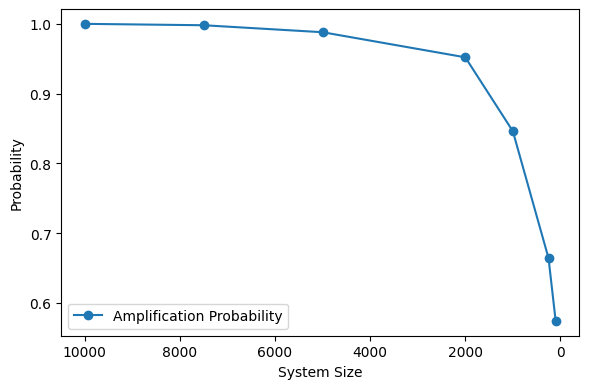

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(system_sizes, amp_results, 'o-', label="Amplification Probability")

ax.set_xlabel("System Size")
ax.set_ylabel("Probability")
ax.legend()

fig.tight_layout()
ax.invert_xaxis()
plt.show()

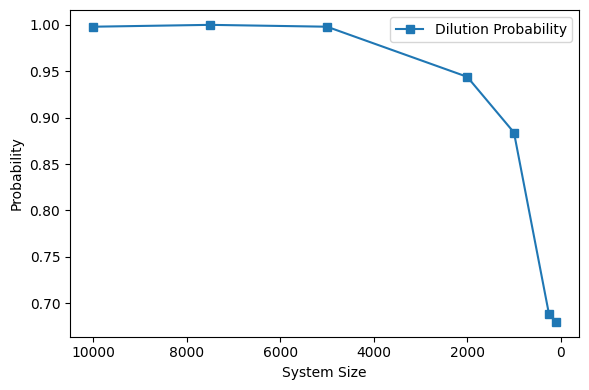

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(system_sizes, dilution_results, 's-', label="Dilution Probability")

ax.set_xlabel("System Size")
ax.set_ylabel("Probability")
ax.legend()

fig.tight_layout()
ax.invert_xaxis()
plt.show()

In [ ]:
for result, system_size in zip(system_sizes, dilution_results):
    print(f"{system_size} : {result}")

0.68 : 100
0.688 : 250
0.884 : 1000
0.944 : 2000
0.998 : 5000
1.0 : 7500
0.998 : 10000


In [ ]:
for result, system_size in zip(system_sizes, amp_results):
    print(f"{system_size} : {result}")

0.574 : 100
0.664 : 250
0.846 : 1000
0.952 : 2000
0.988 : 5000
0.998 : 7500
1.0 : 10000
